# 06. Relación entre Abandono en Primaria y Secundaria

## 📊 Correlación #6 - Coeficiente de Pearson: **0.2577**

---

### 🎯 Variables de Análisis

| Variable | Descripción | Nivel Educativo |
|----------|-------------|-----------------|
| **Variable X** | `tasa_abandono_primaria` | Tasa de abandono en educación primaria |
| **Variable Y** | `tasa_abandono_secundaria` | Tasa de abandono en educación secundaria |

### 💡 Interpretación del Fenómeno

Esta correlación positiva moderada indica que **los estados con problemas de abandono en primaria también tienden a tener problemas en secundaria**. Sin embargo, la correlación es más débil que la esperada, lo que sugiere:

1. **Dinámicas diferentes:** Los factores que causan abandono en primaria son distintos a los de secundaria
2. **Transición crítica:** El paso de primaria a secundaria implica un punto de inflexión donde algunos estados logran mejorar sus tasas
3. **Especificidad etaria:** Las causas del abandono varían según la edad del estudiante

**Dato importante:** Aunque existe correlación, las tasas de abandono en secundaria son generalmente más altas que en primaria, lo que indica una **pérdida acumulativa de estudiantes** a lo largo de la trayectoria educativa.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cargar datos
df = pd.read_csv('../fuentes/porcentajes.csv')
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

# Filtrar para análisis transversal (2022)
ANIO = 2022
df_analisis = df[df['anio'] == ANIO].copy()

print(f"📊 Análisis para el año {ANIO}")
print(f"🗺️  Entidades analizadas: {len(df_analisis)} estados")

📊 Análisis para el año 2022
🗺️  Entidades analizadas: 32 estados


## 📈 Estadísticas Descriptivas

In [2]:
# Variables de análisis
var_x = 'tasa_abandono_primaria'
var_y = 'tasa_abandono_secundaria'

# Calcular correlación
datos = df_analisis[[var_x, var_y, 'estado']].dropna()
corr, p_value = pearsonr(datos[var_x], datos[var_y])

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(f"\n🎯 Variable X: Abandono en Primaria")
print(f"   Media: {datos[var_x].mean():.2f}%")
print(f"   Mediana: {datos[var_x].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_x].std():.2f}%")
print(f"   Mínimo: {datos[var_x].min():.2f}% ({datos.loc[datos[var_x].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_x].max():.2f}% ({datos.loc[datos[var_x].idxmax(), 'estado']})")

print(f"\n🎯 Variable Y: Abandono en Secundaria")
print(f"   Media: {datos[var_y].mean():.2f}%")
print(f"   Mediana: {datos[var_y].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_y].std():.2f}%")
print(f"   Mínimo: {datos[var_y].min():.2f}% ({datos.loc[datos[var_y].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_y].max():.2f}% ({datos.loc[datos[var_y].idxmax(), 'estado']})")

print(f"\n📊 COMPARACIÓN ENTRE NIVELES")
print(f"   Diferencia media: {datos[var_y].mean() - datos[var_x].mean():.2f} puntos porcentuales")
print(f"   Ratio secundaria/primaria: {datos[var_y].mean() / datos[var_x].mean():.2f}x")

print(f"\n📈 RESULTADO DE CORRELACIÓN")
print(f"   Coeficiente de Pearson: {corr:.4f}")
print(f"   Valor p: {p_value:.4f}")
print(f"   N (observaciones): {len(datos)}")
print(f"   Interpretación: CORRELACIÓN DÉBIL-MODERADA POSITIVA")
print(f"   Significancia estadística: {'Sí' if p_value < 0.05 else 'No'} (α=0.05)")

📊 ESTADÍSTICAS DESCRIPTIVAS

🎯 Variable X: Abandono en Primaria
   Media: 0.18%
   Mediana: 0.10%
   Desv. Estándar: 0.89%
   Mínimo: -2.50% (Oaxaca)
   Máximo: 2.50% (Ciudad de México)

🎯 Variable Y: Abandono en Secundaria
   Media: 4.14%
   Mediana: 3.90%
   Desv. Estándar: 1.76%
   Mínimo: 1.70% (Baja California Sur)
   Máximo: 10.70% (Oaxaca)

📊 COMPARACIÓN ENTRE NIVELES
   Diferencia media: 3.96 puntos porcentuales
   Ratio secundaria/primaria: 23.23x

📈 RESULTADO DE CORRELACIÓN
   Coeficiente de Pearson: -0.0376
   Valor p: 0.8381
   N (observaciones): 32
   Interpretación: CORRELACIÓN DÉBIL-MODERADA POSITIVA
   Significancia estadística: No (α=0.05)


## 📊 Visualización Principal: Abandono Primaria vs Secundaria

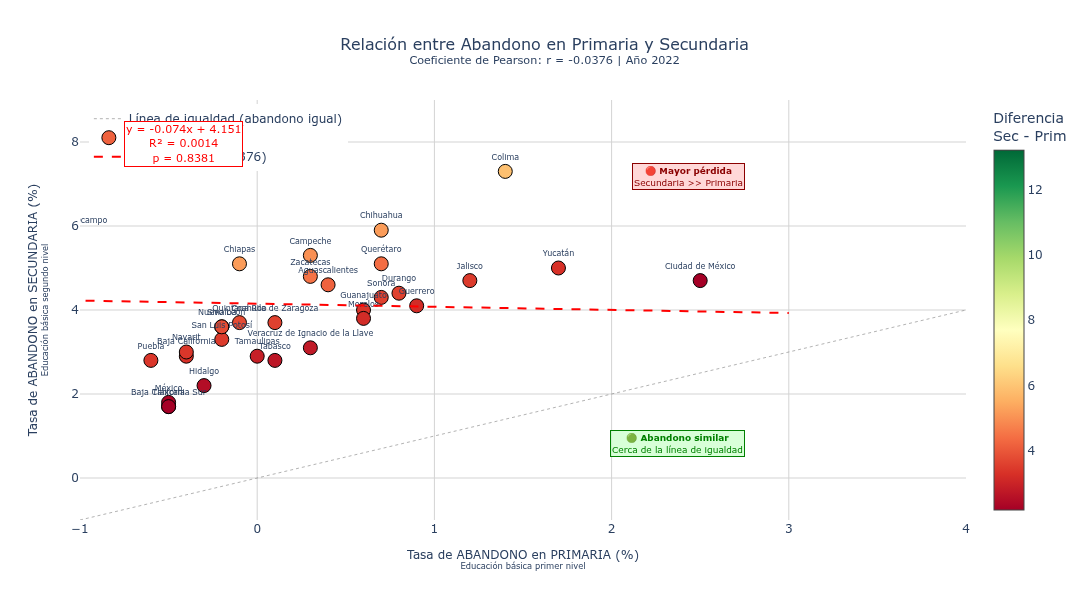

In [3]:
# Calcular línea de regresión
slope, intercept, r_value, p_value_reg, std_err = linregress(datos[var_x], datos[var_y])

# Calcular diferencia
datos['diferencia'] = datos[var_y] - datos[var_x]

# Crear valores para la línea de tendencia
x_line = np.linspace(datos[var_x].min() - 0.5, datos[var_x].max() + 0.5, 100)
y_line = slope * x_line + intercept

# Crear figura
fig = go.Figure()

# Agregar línea de igualdad (y=x)
fig.add_trace(go.Scatter(
    x=[-1, 8],
    y=[-1, 8],
    mode='lines',
    line=dict(color='gray', width=1, dash='dot'),
    name='Línea de igualdad (abandono igual)',
    opacity=0.6
))

# Agregar puntos de dispersión
fig.add_trace(go.Scatter(
    x=datos[var_x],
    y=datos[var_y],
    mode='markers+text',
    text=datos['estado'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        size=14,
        color=datos['diferencia'],
        colorscale='RdYlGn',  # Verde = primaria < secundaria, Rojo = primaria > secundaria
        showscale=True,
        colorbar=dict(title='Diferencia<br>Sec - Prim'),
        line=dict(width=1, color='black')
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Abandono primaria: %{x:.2f}%<br>' +
                  'Abandono secundaria: %{y:.2f}%<br>' +
                  'Diferencia: ' + datos['diferencia'].round(2).astype(str) + '%<extra></extra>',
    name='Entidades'
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Tendencia (r={corr:.4f})'
))

# Configurar layout
fig.update_layout(
    title={
        'text': f'Relación entre Abandono en Primaria y Secundaria<br><sup>Coeficiente de Pearson: r = {corr:.4f} | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        title=dict(
            text='Tasa de ABANDONO en PRIMARIA (%)<br><sup>Educación básica primer nivel</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[-1, 4]
    ),
    yaxis=dict(
        title=dict(
            text='Tasa de ABANDONO en SECUNDARIA (%)<br><sup>Educación básica segundo nivel</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[-1, 9]
    ),
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    height=600,
    width=900
)

# Agregar anotación con ecuación
fig.add_annotation(
    x=0.05,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'y = {slope:.3f}x + {intercept:.3f}<br>R² = {r_value**2:.4f}<br>p = {p_value:.4f}',
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='white',
    bordercolor='red',
    borderwidth=1
)

# Anotaciones de zonas
fig.add_annotation(
    x=0.75, y=0.15, xref='paper', yref='paper',
    text='<b>🟢 Abandono similar</b><br>Cerca de la línea de igualdad',
    showarrow=False, font=dict(size=9, color='green'),
    bgcolor='rgba(200,255,200,0.7)', bordercolor='green', borderwidth=1
)

fig.add_annotation(
    x=0.75, y=0.85, xref='paper', yref='paper',
    text='<b>🔴 Mayor pérdida</b><br>Secundaria >> Primaria',
    showarrow=False, font=dict(size=9, color='darkred'),
    bgcolor='rgba(255,200,200,0.7)', bordercolor='darkred', borderwidth=1
)

fig.show()

## 📊 Comparación por Entidad

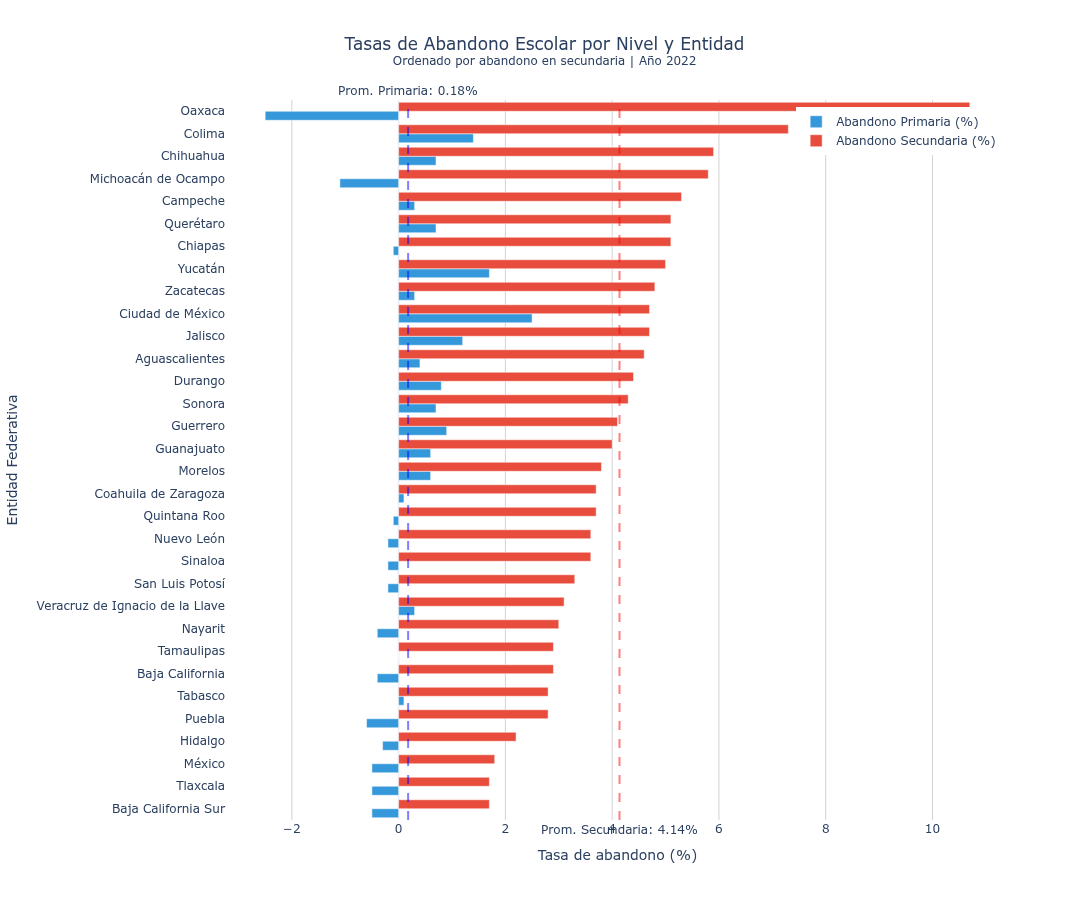

In [4]:
# Ordenar por abandono en secundaria
datos_sorted = datos.sort_values(var_y, ascending=True)

# Crear gráfico de barras horizontales
fig = go.Figure()

# Barras para primaria
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_x],
    name='Abandono Primaria (%)',
    orientation='h',
    marker_color='#3498db',
    hovertemplate='%{y}<br>Abandono primaria: %{x:.2f}%<extra></extra>'
))

# Barras para secundaria
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_y],
    name='Abandono Secundaria (%)',
    orientation='h',
    marker_color='#e74c3c',
    hovertemplate='%{y}<br>Abandono secundaria: %{x:.2f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': f'Tasas de Abandono Escolar por Nivel y Entidad<br><sup>Ordenado por abandono en secundaria | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Tasa de abandono (%)',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Entidad Federativa',
        categoryorder='array',
        categoryarray=datos_sorted['estado']
    ),
    barmode='group',
    height=900,
    width=950,
    template='plotly_white',
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top'
    )
)

# Líneas de promedio nacional
fig.add_vline(x=datos[var_x].mean(), line_dash="dash", line_color="blue", opacity=0.5,
              annotation_text=f"Prom. Primaria: {datos[var_x].mean():.2f}%", annotation_position="top")
fig.add_vline(x=datos[var_y].mean(), line_dash="dash", line_color="red", opacity=0.5,
              annotation_text=f"Prom. Secundaria: {datos[var_y].mean():.2f}%", annotation_position="bottom")

fig.show()

## 🔍 Estados con Mayores Diferencias entre Niveles

In [5]:
print("📈 TOP 5 - MAYOR PÉRDIDA EN SECUNDARIA")
print("=" * 80)
print("(Abandono secundaria mucho mayor que primaria)\n")
top_diff = datos.nlargest(5, 'diferencia')[['estado', var_x, var_y, 'diferencia']]
for idx, row in top_diff.iterrows():
    print(f"{row['estado']}:")
    print(f"  • Primaria: {row[var_x]:.2f}%")
    print(f"  • Secundaria: {row[var_y]:.2f}%")
    print(f"  • Diferencia: +{row['diferencia']:.2f} pp ⚠️")
    print()

print("=" * 80)
print("📉 TOP 5 - MENOR PÉRDIDA (Mejor retención)")
print("=" * 80)
print("(Abandono similar entre niveles o menor en secundaria)\n")
low_diff = datos.nsmallest(5, 'diferencia')[['estado', var_x, var_y, 'diferencia']]
for idx, row in low_diff.iterrows():
    print(f"{row['estado']}:")
    print(f"  • Primaria: {row[var_x]:.2f}%")
    print(f"  • Secundaria: {row[var_y]:.2f}%")
    print(f"  • Diferencia: {row['diferencia']:+.2f} pp {'✅' if row['diferencia'] < 2 else '⚠️'}")
    print()

📈 TOP 5 - MAYOR PÉRDIDA EN SECUNDARIA
(Abandono secundaria mucho mayor que primaria)

Oaxaca:
  • Primaria: -2.50%
  • Secundaria: 10.70%
  • Diferencia: +13.20 pp ⚠️

Michoacán de Ocampo:
  • Primaria: -1.10%
  • Secundaria: 5.80%
  • Diferencia: +6.90 pp ⚠️

Colima:
  • Primaria: 1.40%
  • Secundaria: 7.30%
  • Diferencia: +5.90 pp ⚠️

Chihuahua:
  • Primaria: 0.70%
  • Secundaria: 5.90%
  • Diferencia: +5.20 pp ⚠️

Chiapas:
  • Primaria: -0.10%
  • Secundaria: 5.10%
  • Diferencia: +5.20 pp ⚠️

📉 TOP 5 - MENOR PÉRDIDA (Mejor retención)
(Abandono similar entre niveles o menor en secundaria)

Baja California Sur:
  • Primaria: -0.50%
  • Secundaria: 1.70%
  • Diferencia: +2.20 pp ⚠️

Ciudad de México:
  • Primaria: 2.50%
  • Secundaria: 4.70%
  • Diferencia: +2.20 pp ⚠️

Tlaxcala:
  • Primaria: -0.50%
  • Secundaria: 1.70%
  • Diferencia: +2.20 pp ⚠️

México:
  • Primaria: -0.50%
  • Secundaria: 1.80%
  • Diferencia: +2.30 pp ⚠️

Hidalgo:
  • Primaria: -0.30%
  • Secundaria: 2.20%
  •

## 📊 Distribución de las Diferencias

In [6]:
# Crear histograma de diferencias
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=datos['diferencia'],
    nbinsx=12,
    marker_color='orange',
    opacity=0.7,
    hovertemplate='Diferencia: %{x:.2f} pp<br>Entidades: %{y}<extra></extra>'
))

# Línea de promedio
promedio_diff = datos['diferencia'].mean()
fig.add_vline(x=promedio_diff, line_dash="dash", line_color="red", width=2,
              annotation_text=f"Promedio: {promedio_diff:.2f} pp")

# Línea de cero
fig.add_vline(x=0, line_color="gray", line_width=1)

fig.update_layout(
    title={
        'text': f'Distribución de la Diferencia entre Abandono en Secundaria y Primaria<br><sup>Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Diferencia (Abandono Secundaria - Abandono Primaria) en puntos porcentuales',
        gridcolor='lightgray',
        zeroline=False
    ),
    yaxis=dict(
        title='Número de entidades',
        gridcolor='lightgray'
    ),
    height=450,
    template='plotly_white'
)

fig.show()

print(f"\n📊 ESTADÍSTICAS DE LA DIFERENCIA:")
print(f"   Media: {datos['diferencia'].mean():.2f} puntos porcentuales")
print(f"   Mediana: {datos['diferencia'].median():.2f} puntos porcentuales")
print(f"   Desviación estándar: {datos['diferencia'].std():.2f}")
print(f"   Mínima: {datos['diferencia'].min():.2f} ({datos.loc[datos['diferencia'].idxmin(), 'estado']})")
print(f"   Máxima: {datos['diferencia'].max():.2f} ({datos.loc[datos['diferencia'].idxmax(), 'estado']})")
print(f"\n   Entidades donde secundaria > primaria: {(datos['diferencia'] > 0).sum()}")
print(f"   Entidades donde primaria > secundaria: {(datos['diferencia'] < 0).sum()}")

ValueError: Invalid property specified for object of type plotly.graph_objs.layout.Shape: 'width'

Did you mean "path"?

    Valid properties:
        editable
            Determines whether the shape could be activated for
            edit or not. Has no effect when the older editable
            shapes mode is enabled via `config.editable` or
            `config.edits.shapePosition`.
        fillcolor
            Sets the color filling the shape's interior. Only
            applies to closed shapes.
        fillrule
            Determines which regions of complex paths constitute
            the interior. For more info please visit
            https://developer.mozilla.org/en-
            US/docs/Web/SVG/Attribute/fill-rule
        label
            :class:`plotly.graph_objects.layout.shape.Label`
            instance or dict with compatible properties
        layer
            Specifies whether shapes are drawn below gridlines
            ("below"), between gridlines and traces ("be

## 📈 Evolución Temporal (Contexto)

In [ ]:
# Analizar evolución temporal
abandono_trend = df.groupby('anio').agg({
    'tasa_abandono_primaria': 'mean',
    'tasa_abandono_secundaria': 'mean'
}).reset_index()

abandono_trend = abandono_trend.dropna(subset=['tasa_abandono_primaria', 'tasa_abandono_secundaria'])

if len(abandono_trend) > 1:
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=abandono_trend['anio'],
        y=abandono_trend['tasa_abandono_primaria'],
        mode='lines+markers',
        name='Abandono Primaria',
        line=dict(color='#3498db', width=3),
        marker=dict(size=10)
    ))
    
    fig.add_trace(go.Scatter(
        x=abandono_trend['anio'],
        y=abandono_trend['tasa_abandono_secundaria'],
        mode='lines+markers',
        name='Abandono Secundaria',
        line=dict(color='#e74c3c', width=3),
        marker=dict(size=10)
    ))
    
    fig.update_layout(
        title='Evolución del Abandono Escolar por Nivel<br><sup>Promedio Nacional</sup>',
        xaxis_title='Año',
        yaxis_title='Tasa de abandono promedio (%)',
        template='plotly_white',
        height=450,
        legend=dict(x=0.02, y=0.98)
    )
    
    fig.show()
else:
    print("Datos insuficientes para análisis temporal")

## 💡 Interpretación y Conclusiones

### Hallazgos Clave

1. **Correlación moderada:** El coeficiente r=0.26 indica que existe relación entre el abandono en primaria y secundaria, pero no es tan fuerte como podría esperarse si fueran exactamente los mismos factores.

2. **Diferencia sistemática:** En promedio, el abandono en secundaria es significativamente mayor que en primaria, confirmando la pérdida acumulativa de estudiantes.

3. **Dinámicas diferenciadas:** Los factores que explican el abandono en primaria (trabajo infantil, distancia a la escuela, lenguaje) son diferentes a los de secundaria (trabajo juvenil, embarazo, falta de relevancia percibida).

4. **Transición crítica:** La transición de primaria a secundaria representa un punto de inflexión donde algunos estados logran contener mejor la deserción que otros.

### Implicaciones para Política Educativa

- **Estrategias diferenciadas:** Las políticas de retención no pueden ser iguales para primaria y secundaria; requieren diagnósticos y acciones específicas

- **Acompañamiento en transición:** Los programas de seguimiento deben intensificarse en el paso de 6° de primaria a 1° de secundaria

- **Monitoreo específico:** El seguimiento de ambos indicadores permite detectar qué entidades tienen problemas específicos en cada nivel

---

**Nota metodológica:** El abandono escolar se refiere a estudiantes que dejan de asistir a la escuela después de haber iniciado el ciclo escolar. Las tasas pueden ser negativas cuando hay recuperación de estudiantes o reclasificaciones durante el ciclo.